In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu
from collections import defaultdict, Counter

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [63]:
fp_proc_moth_data = '/Users/tplas/data/2025-06-16 moth data Natalie/1994-2019_field-d50.csv'
assert os.path.exists(fp_proc_moth_data)

# df_proc = pd.read_csv(fp_proc_moth_data, sep=';')
df_proc = pd.read_excel('/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_D50_AllClutches_CommonGarden.xlsx')
df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc
0,1994,1995,HV,98,4,15,5944,CG1995,15.0
1,1994,1995,HV,98,44,15,5946,CG1995,8.0
2,1994,1995,HV,98,11,15,5947,CG1995,1.0
3,1994,1995,HV,98,41,15,5949,CG1995,8.0
4,1994,1995,HV,98,41,15,5950,CG1995,8.0
...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9


In [10]:
fp_raw_moth_data = '/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_NumberOfCaterpillarsPerClutchPerDay.txt'
assert os.path.exists(fp_raw_moth_data)

## read as csv 
df_raw = pd.read_csv(fp_raw_moth_data, sep=';')

df_raw.groupby('TubeID')

In [22]:
df_tmp = df_raw[:50]
## Sum Caterpillars per TubeID

def add_relative_caterpillar_counts(df, remove_zero_tubes=True):
    df = df.copy()
    df_cp_per_tube = df.groupby(['TubeID']).agg({'Caterpillars':'sum'}).reset_index()
    df['TotalCaterpillarsPerTube'] = df['TubeID'].map(df_cp_per_tube.set_index('TubeID')['Caterpillars'])
    if remove_zero_tubes:
        df = df[df['TotalCaterpillarsPerTube'] > 0]
    df['RelativeCaterpillarsPerTube'] = df['Caterpillars'] / df['TotalCaterpillarsPerTube']
    df['CumulativeRelativeCaterpillarsPerTube'] = df.groupby('TubeID')['RelativeCaterpillarsPerTube'].cumsum()
    return df 

df_raw = add_relative_caterpillar_counts(df_raw)

In [23]:
df_raw

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars,TotalCaterpillarsPerTube,RelativeCaterpillarsPerTube,CumulativeRelativeCaterpillarsPerTube
0,1994,1995,HV,98,4,15,5944,CG1995,-14,0.0,30.0,0.000000,0.000000
1,1994,1995,HV,98,4,15,5944,CG1995,-1,0.0,30.0,0.000000,0.000000
2,1994,1995,HV,98,4,15,5944,CG1995,5,0.0,30.0,0.000000,0.000000
3,1994,1995,HV,98,4,15,5944,CG1995,11,0.0,30.0,0.000000,0.000000
4,1994,1995,HV,98,4,15,5944,CG1995,19,30.0,30.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119003,2024,2025,WA,2,12,25,21400,CG2025,10,6.0,223.0,0.026906,0.959641
119004,2024,2025,WA,2,12,25,21400,CG2025,16,8.0,223.0,0.035874,0.995516
119005,2024,2025,WA,2,12,25,21400,CG2025,17,1.0,223.0,0.004484,1.000000
119006,2024,2025,WA,2,12,25,21400,CG2025,22,0.0,223.0,0.000000,1.000000


In [17]:
df_raw[np.logical_and(df_raw.YearHatch == 1998, df_raw.Tree == 3)]

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars
4582,1997,1998,DO,1,3,13,1040,CG1998,-11,0.0
4583,1997,1998,DO,1,3,13,1040,CG1998,-6,0.0
4584,1997,1998,DO,1,3,13,1040,CG1998,-1,0.0
4585,1997,1998,DO,1,3,13,1040,CG1998,6,0.0
4586,1997,1998,DO,1,3,13,1040,CG1998,9,0.0
...,...,...,...,...,...,...,...,...,...,...
4863,1997,1998,DO,6,3,33,1068,CG1998,14,2.0
4864,1997,1998,DO,6,3,33,1068,CG1998,17,5.0
4865,1997,1998,DO,6,3,33,1068,CG1998,20,0.0
4866,1997,1998,DO,6,3,33,1068,CG1998,24,0.0


In [16]:
df_proc[np.logical_and(df_proc.YearHatch == 1998, df_proc.Tree == 3)]

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeNumber,D50Calc
429,1997,1998,DO,1,3,27,21,"3,6"
430,1997,1998,DO,1,3,27,23,"11,5"
432,1997,1998,DO,4,3,27,25,"11,5"
433,1997,1998,DO,4,3,27,26,6
434,1997,1998,DO,4,3,27,28,6
438,1997,1998,DO,6,3,27,32,"8,4"
439,1997,1998,DO,6,3,27,33,"14,6"
462,1997,1998,DO,1,3,33,68,"8,8"
464,1997,1998,DO,4,3,33,71,"14,9"


In [35]:
def calculate_d50(df, column='Caterpillars', verbose=0):
    assert 'TubeID' in df.columns and column in df.columns and 'AprilDay' in df.columns
    max_cp = int(df[column].max())
    if max_cp == 0.0:
        if verbose:
            print("WARNING: max_cp is 0.0"
                  f" for TubeID {df.TubeID.values[0]}")
        return np.nan
    
    if column == 'RelativeCaterpillarsPerTube':
        half_cp = 0.5
        max_cp = 1.0
    else:
        half_cp = max_cp / 2

    ## get the first day where the caterpillars are above half_cp
    df_half_top = df[df[column] >= half_cp]
    day_top = df_half_top.AprilDay.min()
    count_top = df_half_top[df_half_top.AprilDay == day_top][column].values[0]
    # count_top = df_half_top[column].min()
    # day_top = df_half_top[df_half_top[column] == count_top].AprilDay.values[0]

    ## get the last day where the caterpillars are below half_cp
    df_half_bottom = df[df[column] <= half_cp]
    if df_half_bottom.shape[0] == 0 or df_half_bottom[column].max() == 0.0:
        if verbose:
            print("WARNING: no bottom half found"
                f" for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return np.nan
    
    else:
        count_bottom = df_half_bottom[column].max()
        day_bottom = df_half_bottom[df_half_bottom[column] == count_bottom].AprilDay.values[0]

    if verbose:
        print(f"TubeID {df.TubeID.values[0]}: max_cp {max_cp}, half_cp {half_cp}, "
              f"day_bottom {day_bottom} (count_bottom {count_bottom}), "
              f"day_top {day_top} (count_top {count_top})")
        
    if count_top == count_bottom:
        if verbose:
            print("count_top == count_bottom"
                  f" for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return day_top
    
    # linear interpolation to find the day where the count is exactly half_cp
    d50 = day_bottom + (half_cp - count_bottom) * (day_top - day_bottom) / (count_top - count_bottom)
    return float(d50)

In [67]:
tube_id = 1050

print(calculate_d50(df_raw[df_raw.TubeID == tube_id], column='CumulativeRelativeCaterpillarsPerTube', verbose=1))

df_raw[df_raw.TubeID == tube_id]

TubeID 1050: max_cp 1, half_cp 0.5, day_bottom -1 (count_bottom 0.3333333333333333), day_top 14 (count_top 0.6666666666666666)
6.500000000000002


,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars,TotalCaterpillarsPerTube,RelativeCaterpillarsPerTube,CumulativeRelativeCaterpillarsPerTube
4678,1997,1998,DO,4,3,27,1050,CG1998,-11,0.0,45.0,0.000000,0.000000
4679,1997,1998,DO,4,3,27,1050,CG1998,-6,0.0,45.0,0.000000,0.000000
4680,1997,1998,DO,4,3,27,1050,CG1998,-1,15.0,45.0,0.333333,0.333333
4681,1997,1998,DO,4,3,27,1050,CG1998,6,0.0,45.0,0.000000,0.333333
4682,1997,1998,DO,4,3,27,1050,CG1998,9,0.0,45.0,0.000000,0.333333
4683,1997,1998,DO,4,3,27,1050,CG1998,14,15.0,45.0,0.333333,0.666667
4684,1997,1998,DO,4,3,27,1050,CG1998,17,15.0,45.0,0.333333,1.000000
4685,1997,1998,DO,4,3,27,1050,CG1998,20,0.0,45.0,0.000000,1.000000
4686,1997,1998,DO,4,3,27,1050,CG1998,24,0.0,45.0,0.000000,1.000000
4687,1997,1998,DO,4,3,27,1050,CG1998,27,0.0,45.0,0.000000,1.000000


In [64]:
df_proc[np.logical_and(np.logical_and(df_proc.YearHatch == 1998, df_proc.Tree == 3), df_proc.Site == 4)]
# df_proc[df_proc.TubeID == 1050]

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc
382,1997,1998,DO,4,3,27,1050,CG1998,11.5
383,1997,1998,DO,4,3,27,1051,CG1998,6.0
384,1997,1998,DO,4,3,27,1052,CG1998,6.0
385,1997,1998,DO,4,3,33,1054,CG1998,14.9


In [52]:
df_proc['match'] = np.nan 
for i, row in df_proc.iterrows():
    tube_id = row['TubeID']
    if tube_id in df_raw.TubeID.values:
        d50_calc = calculate_d50(df_raw[df_raw.TubeID == tube_id], 
                                 column='CumulativeRelativeCaterpillarsPerTube', verbose=0)
        df_proc.at[i, 'match'] = d50_calc

df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,match
0,1994,1995,HV,98,4,15,5944,CG1995,15.0,NaN
1,1994,1995,HV,98,44,15,5946,CG1995,8.0,NaN
2,1994,1995,HV,98,11,15,5947,CG1995,1.0,1.000000
3,1994,1995,HV,98,41,15,5949,CG1995,8.0,NaN
4,1994,1995,HV,98,41,15,5950,CG1995,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2,4.156863
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0,5.980198
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8,7.757576
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9,9.933333


In [55]:
unique_tubes_raw_data = df_raw.TubeID.unique()
unique_tubes_proc_data = df_proc.TubeID.unique()

raw_tubes_not_in_proc = [tube for tube in unique_tubes_raw_data if tube not in unique_tubes_proc_data]
proc_tubes_not_in_raw = [tube for tube in unique_tubes_proc_data if tube not in unique_tubes_raw_data]

print(f"Tubes in raw data but not in processed data: {len(raw_tubes_not_in_proc)}, tubes in processed data but not in raw data: {len(proc_tubes_not_in_raw)}")

Tubes in raw data but not in processed data: 534, tubes in processed data but not in raw data: 0


Text(0.5, 1.0, 'Comparison of D50Calc Values')

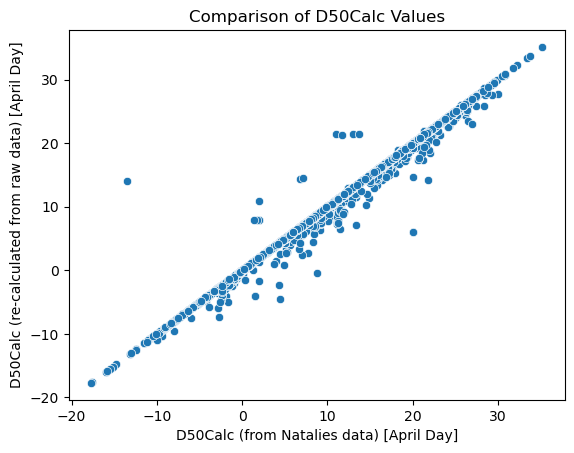

In [56]:
import seaborn as sns

sns.scatterplot(data=df_proc, x='D50Calc', y='match')
plt.xlabel('D50Calc (from Natalies data) [April Day]')
plt.ylabel('D50Calc (re-calculated from raw data) [April Day]')
plt.title('Comparison of D50Calc Values')